## Численное решение обыкновенных дифференциальных уравнений

In [1]:
from scipy.integrate import solve_ivp

дополнительные импорты для задания векторов

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time # для засекания времени работы

In [3]:
def f(t, y):
    return -y

sol = solve_ivp(f, (0, 5), [1.0])

In [4]:
sol.t

array([0.        , 0.10001999, 1.03186487, 1.90765136, 2.78720278,
       3.66720722, 4.54883436, 5.        ])

In [5]:
sol.y

array([[1.        , 0.90481933, 0.35660435, 0.14860781, 0.06169755,
        0.02560344, 0.01060783, 0.00675601]])

In [6]:
sol.success

True

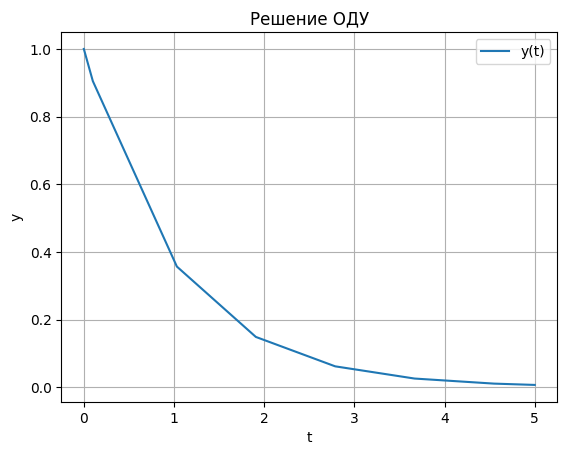

In [7]:
# иллюстрация решения
plt.figure()
plt.plot(sol.t, sol.y[0], label="y(t)")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Решение ОДУ")
plt.grid()
plt.legend()
plt.show()

## Задание сетки решения

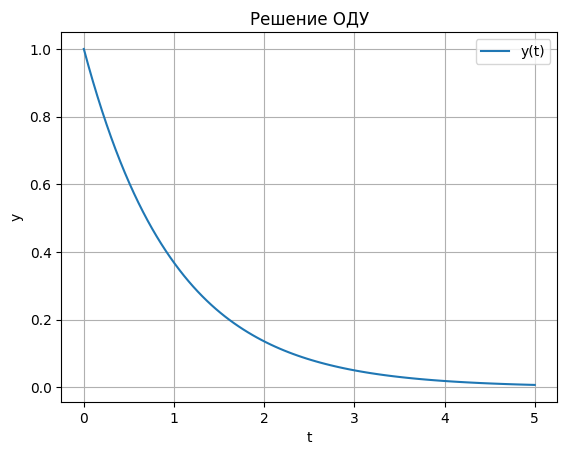

In [8]:
t_eval = np.linspace(0, 5, 100)

sol = solve_ivp(f, (0, 5), [1.0], t_eval=t_eval)
# иллюстрация решения
plt.figure()
plt.plot(sol.t, sol.y[0], label="y(t)")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Решение ОДУ")
plt.grid()
plt.legend()
plt.show()

## События

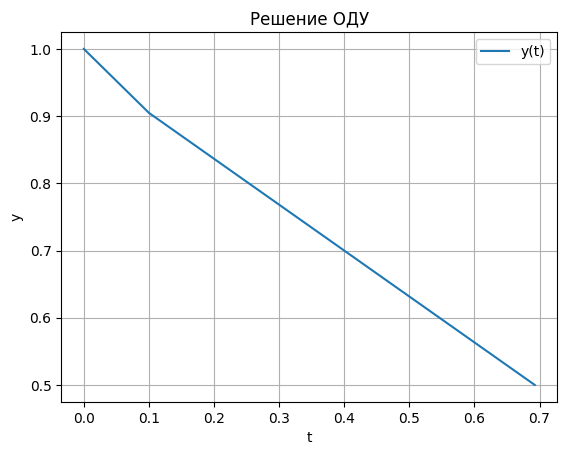

In [9]:
def event(t, y):
    return y[0] - 0.5

event.terminal = True
event.direction = -1

sol = solve_ivp(f, (0, 5), [1.0], events=event)
# иллюстрация решения
plt.figure()
plt.plot(sol.t, sol.y[0], label="y(t)")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Решение ОДУ")
plt.grid()
plt.legend()
plt.show()

## Решение краевой задачи

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

# система уравнений
def fun(x, y):
    return np.vstack((y[1], -y[0]))

# граничные условия
def bc(ya, yb):
    return np.array([ya[0], yb[0] - 1])

# начальная сетка
x = np.linspace(0, np.pi/2, 10)

# начальное приближение (2 строки: y и y')
y_init = np.zeros((2, x.size))

# решение
sol = solve_bvp(fun, bc, x, y_init)


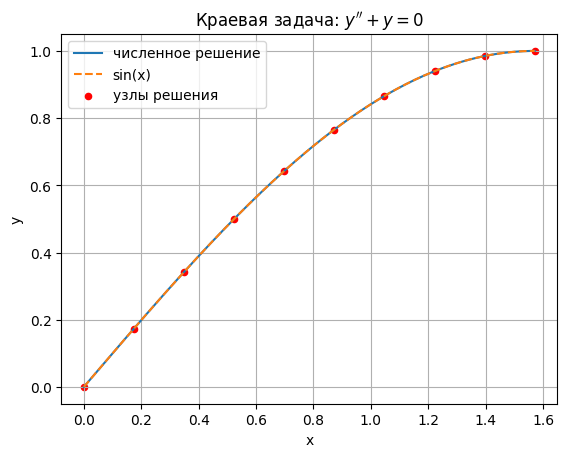

In [11]:
# плотная сетка для отрисовки
x_plot = np.linspace(0, np.pi/2, 200)
y_plot = sol.sol(x_plot)

# аналитическое решение для сравнения
y_true = np.sin(x_plot)

# отрисовка
plt.figure()
plt.plot(x_plot, y_plot[0], label="численное решение")
plt.plot(x_plot, y_true, "--", label="sin(x)")
plt.scatter(x, sol.y[0], color="red", s=20, label="узлы решения")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Краевая задача: $y'' + y = 0$")
plt.grid()
plt.legend()
plt.show()

In [12]:
# правая часть системы
def vanderp(t, y):
    y1, y2 = y
    dy1 = y2
    dy2 = -y1 + 0.3 * y2 * (1 - y1**2)
    return [dy1, dy2]

# начальные условия
y0 = [1, 0]

# интервал интегрирования
t_span = (0, 30)

# точки для вывода решения
t_eval = np.linspace(0, 30, 1000)

# решение
sol = solve_ivp(vanderp, t_span, y0, t_eval=t_eval)

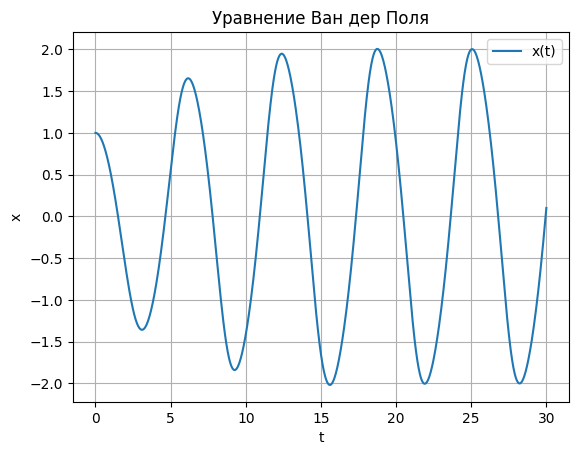

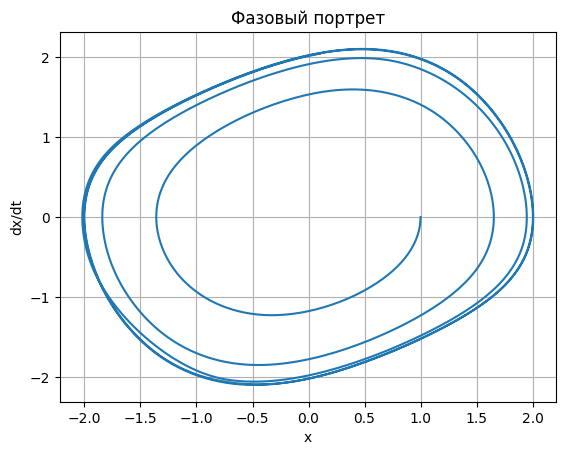

In [13]:
# отрисовка решения x(t)
plt.figure()
plt.plot(sol.t, sol.y[0], label="x(t)")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Уравнение Ван дер Поля")
plt.grid()
plt.legend()
plt.savefig('van-der-pol-pic1.png')
plt.show()

# фазовый портрет
plt.figure()
plt.plot(sol.y[0], sol.y[1])
plt.xlabel("x")
plt.ylabel("dx/dt")
plt.title("Фазовый портрет")
plt.grid()
plt.savefig('van-der-pol-pic2.png')
plt.show()

## Пример моделирования механической системы с сухим трением

In [14]:
# неизменяемые параметры системы
c = 1.0      # коэффициент упругости
k = 0.02     # коэффициент демпфирования
m = 1.0      # масса
g = 9.8      # ускорение свободного падения
mu = 0.5     # коэффициент трения
v = 4.0      # скорость ленты, для этого примера величина строго больше 0

# параметры в кортеже
sys_args = (c, k, m, g, mu, v)

In [15]:
#  шаг интегрирования (параметр можно использовать, или нет: сравните результат самостоятельно)
dt = 0.0005

In [16]:
# Варьируемые параметры

# интервал времени
T0 = 0.0
Tf = 30.0

# начальные условия [координата, скорость]
y0 = np.array([-15, 9.0], dtype=float)

In [17]:
# Функции

# правая часть на участке скольжения
def ft(t, y, c, k, m, g, mu, v, sgn):
    f = np.zeros(2, dtype=float)
    f[0] = y[1]
    f[1] = -c / m * y[0] - k / m * y[1] - mu * g * sgn
    return f
    
# событие: скорость тела сравнялась со скоростью ленты
def events(t, y, c, k, m, g, mu, v, sgn):
    return y[1] - v

In [18]:
# основной код решения задачи

# настройка срабатывания событий
events.terminal = True # по событию идет остановка интегрирования
events.direction = 0 # смена знака в любом направлении
       
# накопители решения
T_parts = []
Y_parts = []

# начальные условия
t_cur = T0
y_cur = y0.copy()
eps_t = 1e-8

time_start = time.time() # для замера 
while t_cur < Tf:
    # текущий знак силы трения на участке скольжения
    sgn = np.sign(y_cur[1] - v)
    if sgn == 0:
        f0 = ft(t_cur, y_cur, c, k, m, g, mu, v, sgn)
        # обновляем начальные условия
        y_cur = y_cur + eps_t * np.array(f0) 
        t_cur = t_cur + eps_t
        sgn = np.sign(y_cur[1] - v)

    # интегрируем участок скольжения до события y2 = v или до конца интервала
    sol_slip = solve_ivp(
        ft,
        (t_cur, Tf),
        y_cur,
        method="RK45",
        events=events,
        args=(*sys_args, sgn),
        dense_output=False,
        max_step=dt,
    )
    T_parts.append(sol_slip.t)
    Y_parts.append(sol_slip.y)

    # если события не было, дошли до конца интервала
    if sol_slip.t_events[0].size == 0:
        break

    # точка события: y2 = v
    t_hit = sol_slip.t_events[0][0]
    y_hit = sol_slip.y_events[0][0].copy()
    # информационная печать
    print('точка остановки интегрирования: y2 = v', t_hit, y_hit)

    # проверяем условие прилипания
    # при прилипании y2 = v, поэтому условие: |c*x + k*v| <= mu*m*g
    q_stick = c * y_hit[0] + k * v

    # если условие прилипания не выполнено, продолжаем скольжение
    if np.abs(q_stick) > mu * m * g:
        t_cur = t_hit
        y_cur = y_hit.copy()
        # обновляем начальные условия, отступая от метки события в соответствии с системой
        f0 = ft(t_cur, y_cur, c, k, m, g, mu, v, sgn)
        y_cur = y_cur + eps_t * np.array(f0) 
        t_cur = t_cur + eps_t

    else: # при прилипании
    # момент выхода из прилипания и координата определяются аналитически 
        if np.abs(v) < 1e-15:
            # частный случай: лента неподвижна, положение не меняется на участке прилипания
            # тогда остаёмся в этом состоянии до конца
            t_leave = Tf
        else:
            x_m = (mu * m * g - k * v) / c # аналитически вычисленная точка начала скольжения
            tau = (x_m - y_hit[0]) / v # время движения груза с лентой в прилипшем состоянии
            t_leave = t_hit + tau # момент времени начала скольжения по ленте после прилипания
            # строим аналитический участок
            T_parts.append(t_leave)
            Y_stick = np.vstack((x_m, v))
            Y_parts.append(Y_stick)
            # в момент выхода из прилипания задаём начальные условия для нового скольжения
            y_cur = np.array([x_m, v], dtype=float)
            t_cur = t_leave
elapsed = time.time() - time_start
print('Время интегрирования:  ', elapsed)

точка остановки интегрирования: y2 = v 2.101088336472354 [7.61935315 4.        ]
точка остановки интегрирования: y2 = v 7.2583745327694915 [2.5578477 4.       ]
Время интегрирования:   1.680830955505371


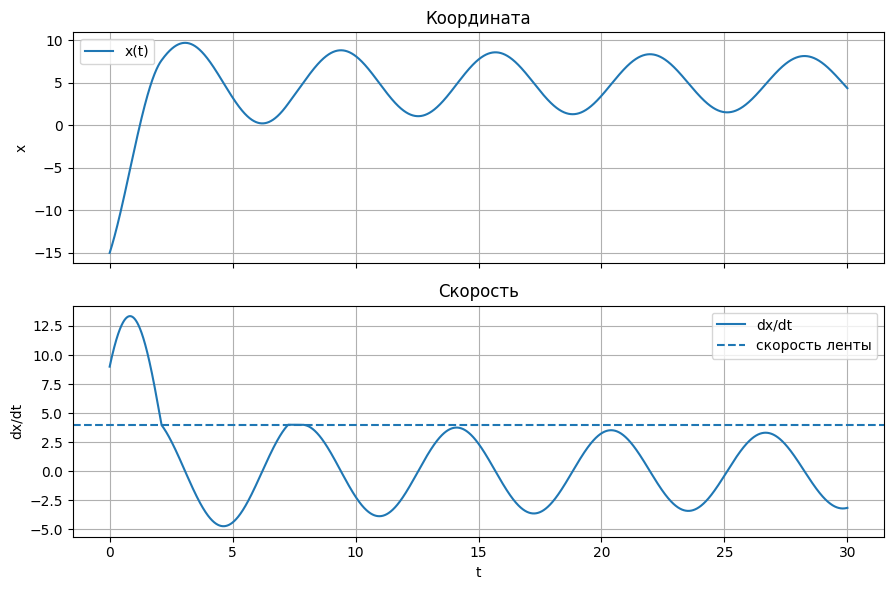

In [19]:
# =========================
# склейка результатов
# =========================
T_full = []
Y_full = []

for i, (tt, yy) in enumerate(zip(T_parts, Y_parts)):
    tt = np.atleast_1d(tt)
    yy = np.asarray(yy, dtype=float)

    # приводим yy к форме (2, n_points)
    if yy.ndim == 1:
        yy = yy.reshape(2, 1)

    # если в yy одна точка, а tt скаляр или длины 1
    if i == 0:
        T_full.extend(tt.tolist())
        Y_full.extend(yy.T.tolist())
    else:
        # убираем повтор первой точки очередного куска, если он есть
        if len(tt) > 1:
            T_full.extend(tt[1:].tolist())
            Y_full.extend(yy.T[1:].tolist())
        else:
            T_full.extend(tt.tolist())
            Y_full.extend(yy.T.tolist())

T_full = np.array(T_full, dtype=float)
Y_full = np.array(Y_full, dtype=float).T

# =========================
# отрисовка координаты и скорости
# =========================
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(T_full, Y_full[0], label="x(t)")
axes[0].set_ylabel("x")
axes[0].set_title("Координата")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(T_full, Y_full[1], label="dx/dt")
axes[1].axhline(v, linestyle="--", label="скорость ленты")
axes[1].set_xlabel("t")
axes[1].set_ylabel("dx/dt")
axes[1].set_title("Скорость")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig('dry_friction_pos_seminar.png')
plt.show()

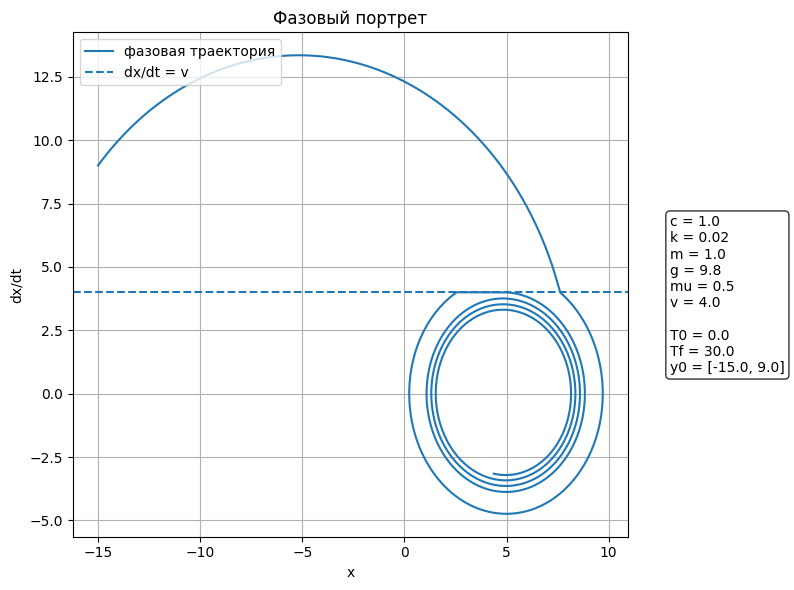

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))

# фазовый портрет
ax.plot(Y_full[0], Y_full[1], label="фазовая траектория")
ax.axhline(v, linestyle="--", label="dx/dt = v")

ax.set_xlabel("x")
ax.set_ylabel("dx/dt")
ax.set_title("Фазовый портрет")
ax.grid(True)
ax.legend(loc="upper left")

# текст с параметрами
params_text = (
    f"c = {c}\n"
    f"k = {k}\n"
    f"m = {m}\n"
    f"g = {g}\n"
    f"mu = {mu}\n"
    f"v = {v}\n\n"
    f"T0 = {T0}\n"
    f"Tf = {Tf}\n"
    f"y0 = [{y0[0]}, {y0[1]}]"
)

# добавляем текст справа от графика
fig.text(
    0.75, 0.5, params_text,
    fontsize=10,
    va="center",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# оставляем место справа
plt.tight_layout(rect=[0, 0, 0.72, 1])
plt.savefig('dry_friction_phase_seminar.png')
plt.show()

### Пример из текста методички

Модель с сухим трением с параметрами из текста методички ($k = 0.001$, $\mu = 0.1$, $y_0 = [0, 6]$). По этой ячейке построены рисунки `dry_friction_pos.png` и `dry_friction_phase.png` в пособии.

Отличия от варианта выше: сдвиг с поверхности события выполняется малым шагом `eps_t`, участок прилипания сохраняется двумя точками (это отрезок прямой), цикл защищён счётчиком итераций.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# неизменяемые параметры системы (как в тексте методички)
c = 1.0      # жёсткость пружины
k = 0.001    # коэффициент демпфирования
m = 1.0      # масса
g = 9.8      # ускорение свободного падения
mu = 0.1     # коэффициент трения
v = 4.0      # скорость ленты, для этого примера величина строго больше 0
sys_args = (c, k, m, g, mu, v)

# варьируемые параметры
T0 = 0.0                               # начало интервала
Tf = 30.0                              # конец интервала
y0 = np.array([0, 6.0], dtype=float)   # [координата, скорость]

# параметры численного метода
dt = 5e-4       # максимальный шаг интегрирования (для гладких графиков)
eps_t = 1e-8    # малый сдвиг с поверхности события


# правая часть на участке скольжения; sgn -- знак (dx/dt - v), постоянный на участке
def ft(t, y, c, k, m, g, mu, v, sgn):
    f = np.zeros(2, dtype=float)
    f[0] = y[1]
    f[1] = -c / m * y[0] - k / m * y[1] - mu * g * sgn
    return f


# событие: скорость тела сравнялась со скоростью ленты
def events(t, y, c, k, m, g, mu, v, sgn):
    return y[1] - v


events.terminal = True   # по событию интегрирование останавливается
events.direction = 0     # смена знака в любом направлении

T_parts = []   # накопители решения: моменты времени
Y_parts = []   # и состояния
t_cur = T0
y_cur = y0.copy()          # копия: иначе изменение y_cur изменит y0
n_iter, n_max = 0, 1000    # защита от зацикливания

while t_cur < Tf and n_iter < n_max:
    n_iter += 1
    # текущий знак силы трения на участке скольжения
    sgn = np.sign(y_cur[1] - v)
    if sgn == 0:
        # стоим на поверхности события: сдвигаемся с неё малым шагом Эйлера
        f0 = ft(t_cur, y_cur, *sys_args, sgn)
        y_cur = y_cur + eps_t * f0
        t_cur = t_cur + eps_t
        sgn = np.sign(y_cur[1] - v)

    # участок скольжения до события y2 = v или до конца интервала
    sol_slip = solve_ivp(ft, (t_cur, Tf), y_cur, method="RK45",
                         events=events, args=(*sys_args, sgn), max_step=dt)
    T_parts.append(sol_slip.t)
    Y_parts.append(sol_slip.y)

    # события не было: дошли до конца интервала
    if sol_slip.t_events[0].size == 0:
        break

    # момент и состояние в момент события
    t_hit = sol_slip.t_events[0][0]
    y_hit = sol_slip.y_events[0][0].copy()

    # условие прилипания при dx/dt = v: |c*x + k*v| <= mu*m*g
    q_stick = c * y_hit[0] + k * v
    if np.abs(q_stick) > mu * m * g:
        # прилипания нет: сдвигаемся с поверхности события и продолжаем скольжение
        t_cur = t_hit
        y_cur = y_hit.copy()
        f0 = ft(t_cur, y_cur, *sys_args, sgn)
        y_cur = y_cur + eps_t * f0
        t_cur = t_cur + eps_t
    else:
        # прилипание: точка и момент выхода определяются аналитически
        x_m = (mu * m * g - k * v) / c
        t_leave = min(t_hit + (x_m - y_hit[0]) / v, Tf)
        x_leave = y_hit[0] + v * (t_leave - t_hit)
        # участок прилипания -- отрезок прямой: достаточно двух точек
        T_parts.append(np.array([t_hit, t_leave]))
        Y_parts.append(np.array([[y_hit[0], x_leave], [v, v]]))
        # начальные условия для нового скольжения
        y_cur = np.array([x_leave, v], dtype=float)
        t_cur = t_leave

# склейка участков
T_full = np.concatenate(T_parts)
Y_full = np.hstack(Y_parts)

# координата и скорость
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(T_full, Y_full[0], label="x(t)")
axes[0].set_ylabel("x")
axes[0].set_title("Координата")
axes[0].grid(True)
axes[0].legend()
axes[1].plot(T_full, Y_full[1], label="dx/dt")
axes[1].axhline(v, linestyle="--", label="скорость ленты")
axes[1].set_xlabel("t")
axes[1].set_ylabel("dx/dt")
axes[1].set_title("Скорость")
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.savefig('dry_friction_pos.png')
plt.show()

# фазовый портрет с параметрами справа
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(Y_full[0], Y_full[1], label="фазовая траектория")
ax.axhline(v, linestyle="--", label="dx/dt = v")
ax.set_xlabel("x")
ax.set_ylabel("dx/dt")
ax.set_title("Фазовый портрет")
ax.grid(True)
ax.legend(loc="upper left")
params_text = (f"c = {c}\nk = {k}\nm = {m}\ng = {g}\nmu = {mu}\nv = {v}\n\n"
               f"T0 = {T0}\nTf = {Tf}\ny0 = [{y0[0]}, {y0[1]}]")
fig.text(0.75, 0.5, params_text, fontsize=10, va="center",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout(rect=[0, 0, 0.72, 1])
plt.savefig('dry_friction_phase.png')
plt.show()
